In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from ydata_profiling import ProfileReport

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_parquet('../data/raw/creditcard.parquet')
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]:,}")

Columns: 31
Rows: 284,807


In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# Data Profiling

In [17]:
print(f"\nDtypes:")
print(df.dtypes.value_counts())


Dtypes:
float64    30
int64       1
Name: count, dtype: int64


In [18]:
print(f"\nNulls: {df.isnull().sum().sum()}")
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Nulls: 0

Memory: 70.6 MB


In [19]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [20]:
# Class Balance
fraud_count = df['Class'].sum()
non_fraud_count = len(df) - fraud_count
print(f"Non-Fraud : {non_fraud_count:,} ({non_fraud_count/len(df)*100:.2f}%)")
print(f"Fraud     : {fraud_count:,}     ({fraud_count/len(df)*100:.2f}%)")
print(f"Ratio     : 1 fraud per {non_fraud_count//fraud_count} legitimate")

Non-Fraud : 284,315 (99.83%)
Fraud     : 492     (0.17%)
Ratio     : 1 fraud per 577 legitimate


In [21]:
# Correlation with target (top features)
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print(corr.head(10))

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


# Observations

- the data is very highly imbalanced, only 0.17% are fraud class.
- Since the varibales don't have names, it's hard to make conlcusions based on their meaning.
- The distributions of the features vary. Some of them close to normal, but some of them have strong skewness and maybe outliers.
- One big problem in terms of features can be identifying if the outlying values are outliers or not. This is the most important step for baseline modeling.
- Since the features are not strongly correlated to each other but some of them have high positive and negative correlations. So, multicollinearity should not be a big problem and depending on the influence on the taget, many features can be good predictors.

# Target feature interactions

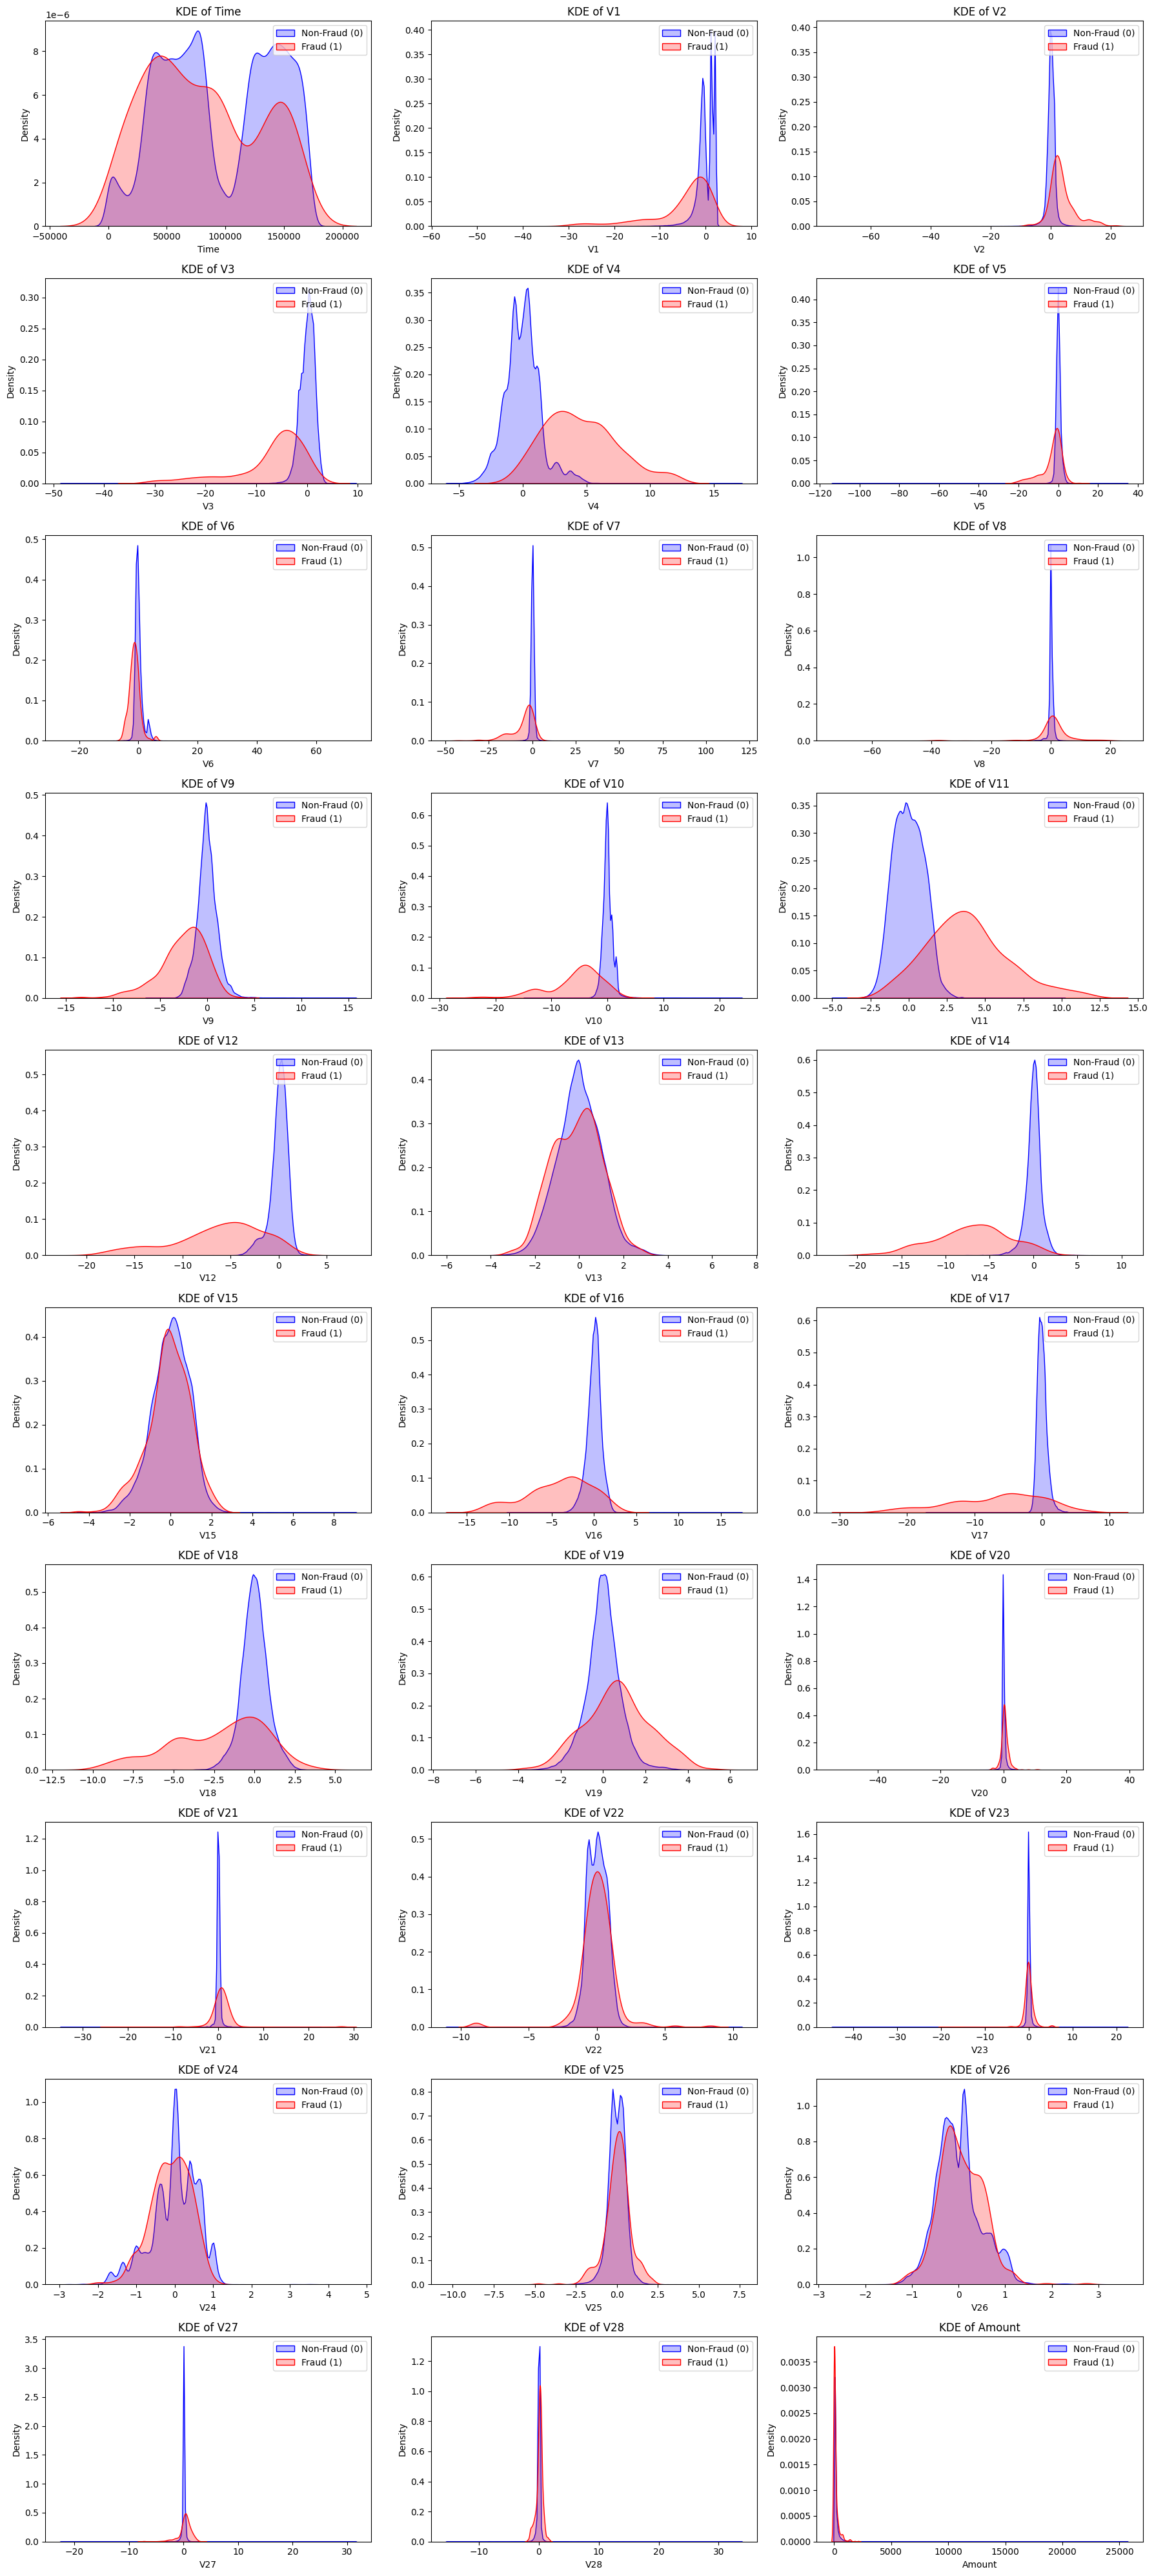

In [27]:
features = [col for col in df.columns if col != 'Class']

# Split fraud and non-fraud
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

# Number of subplots
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # ceiling division

# Set up the plot
plt.figure(figsize=(6 * n_cols, 4 * n_rows))

# Plot KDEs
for i, feat in enumerate(features):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(non_fraud[feat], label='Non-Fraud (0)', color='blue', fill=True, common_norm=False)
    sns.kdeplot(fraud[feat], label='Fraud (1)', color='red', fill=True, common_norm=False)
    ax.set_title(f'KDE of {feat}')
    ax.legend()

plt.tight_layout()
plt.savefig('../images/kde_all_features.png', dpi=100, bbox_inches='tight')


**1. Most Discriminative Features**

The following features show strong separation between fraud and non-fraud distributions:

- V4, V10, V12, 14, V16, V17

Fraud distributions are shifted or have distinct peaks compared to non-fraud. Some of them also have longer tails, especially on the left (e.g., V10, V12, V14).

**2. Moderately Informative Features**

These features show partial overlap between the two classes but still contain useful signals:

- V3, V7, V9, V11, V18, V19, V23, V26

For example, V9 and V11 have longer right tails in the fraud class, while V18 and V26 are visibly skewed. These features may benefit from scaling or interaction with others.

**3. Low-Predictive Features**

These features have almost identical distributions between fraud and non-fraud:

- V13, V15, V20, V21, V22, V25, V2, V28

Their KDE plots overlap almost entirely. Some (like V21, V25, V27) show very sharp spikes and may contain extreme outliers.

**4. Amount Feature**

It's hard to make conclusions from this plot.

**5. Time Feature**

Peaks in fraud activity occur at different times compared to non-fraud.

Suggest extracting time-based features such as hour of day, day of week, or night/weekend indicators.

Time may reflect behavioral patterns of fraudulent activity.


In [28]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Original rows : {len(df):,}")
print(f"Cleaned rows  : {len(df_clean):,}")
print(f"Rows removed  : {len(df) - len(df_clean):,}")

df_clean.to_parquet('../data/processed/creditcard_clean.parquet', index=False)
print(f"Saved to ../data/processed/creditcard_clean.parquet ({len(df_clean):,} rows)")

Original rows : 284,807
Cleaned rows  : 283,726
Rows removed  : 1,081
Saved to ../data/processed/creditcard_clean.parquet (283,726 rows)
